        Unnamed: 0       id                     time        variable  value
0                1  AS14.01  2014-02-26 13:00:00.000            mood   6.00
1                2  AS14.01  2014-02-26 15:00:00.000            mood   6.00
2                3  AS14.01  2014-02-26 18:00:00.000            mood   6.00
3                4  AS14.01  2014-02-26 21:00:00.000            mood   7.00
4                5  AS14.01  2014-02-27 09:00:00.000            mood   6.00
...            ...      ...                      ...             ...    ...
376907     2770399  AS14.30  2014-04-11 07:51:16.948  appCat.weather   8.03
376908     2772465  AS14.30  2014-04-19 11:00:32.747  appCat.weather   3.01
376909     2774026  AS14.30  2014-04-26 10:19:07.434  appCat.weather   7.03
376910     2774133  AS14.30  2014-04-27 00:44:48.450  appCat.weather  23.03
376911     2784435  AS14.32  2014-04-07 18:25:14.036  appCat.weather  22.43

[376912 rows x 5 columns]

 --Unique--
         Unnamed: 0   time  variable  value
id  

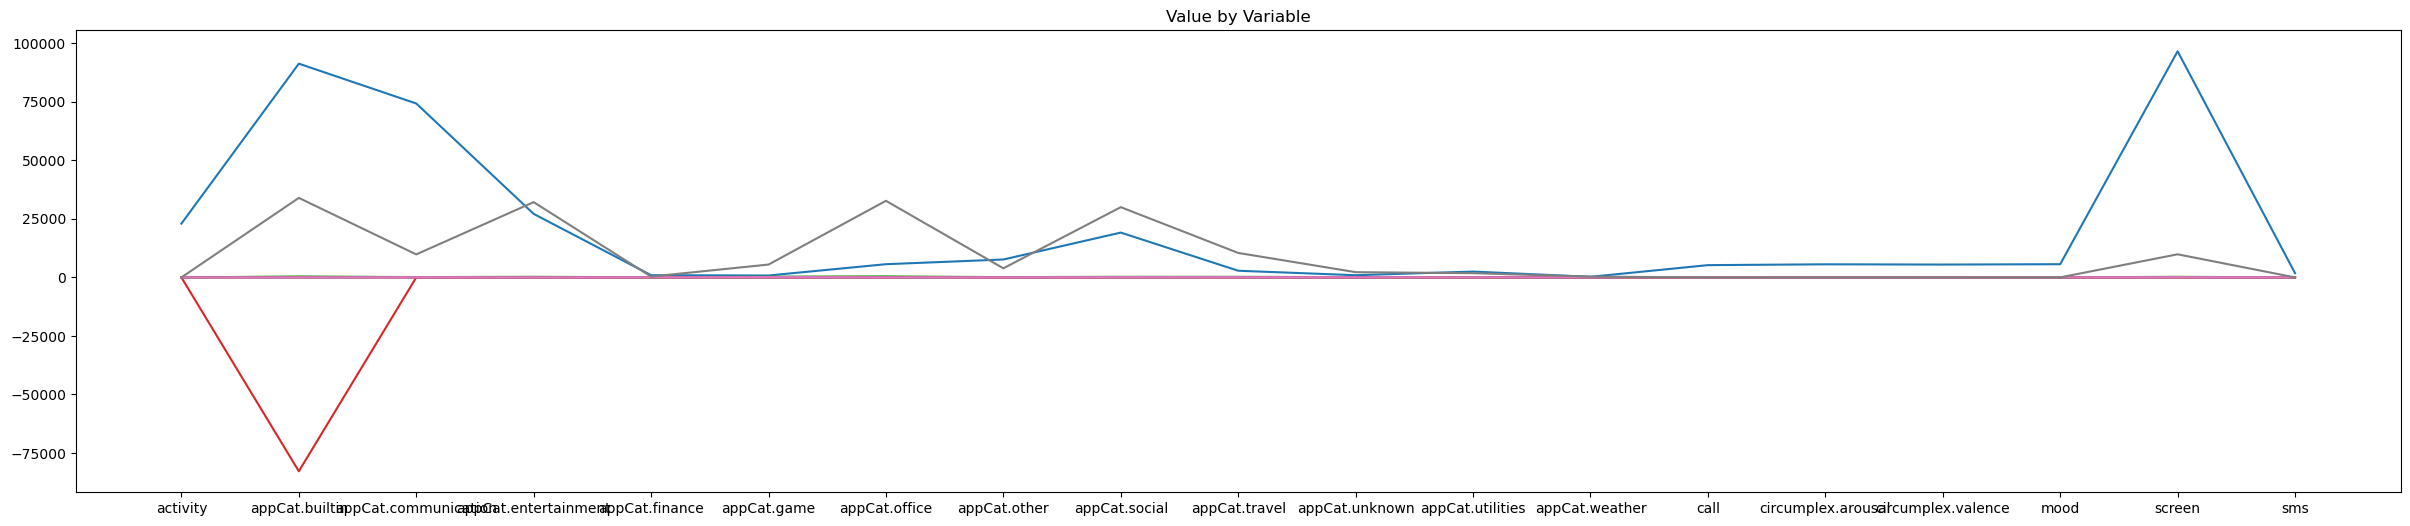

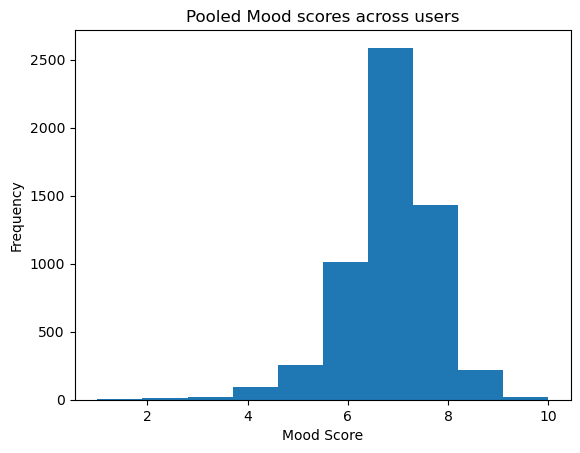

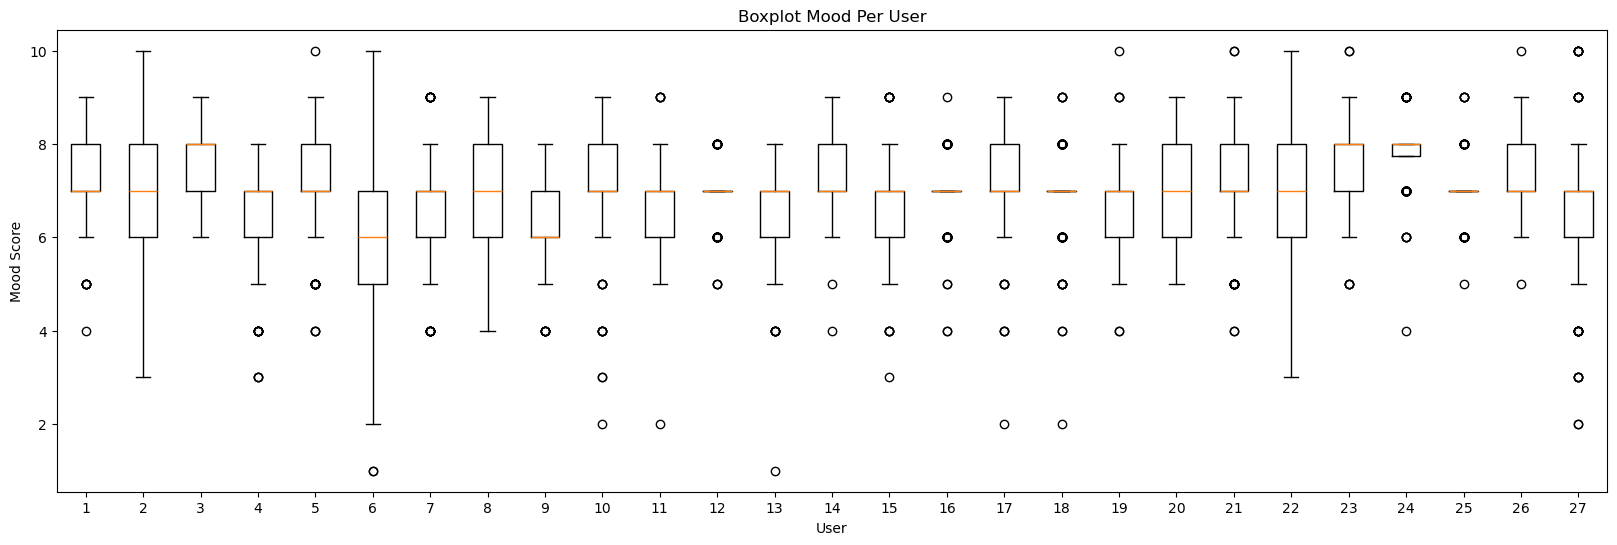

In [1]:
import csv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

mental_health = pd.read_csv("dataset_mood_smartphone.csv")
pd.set_option("display.float_format", lambda x: "%.2f" % x)
print(mental_health)
# print("\n--Info--")
# print(mental_health.info())
# print("\n--Describe--")
# print(mental_health.describe())
# print("\n--IsNull--")
# print(mental_health.isnull().sum())
# print("\n--Unique--")
# print(mental_health.nunique())
# print("\n--Correlation--")
# print(mental_health.corr(numeric_only=True))

df_byVar = mental_health.groupby("variable")["value"].describe()
fig, ax = plt.subplots(figsize=(30, 6))
ax.plot(df_byVar)
ax.set_title("Value by Variable")
fig.savefig("graph.png")

print("\n --Unique--")
print(mental_health.groupby("id").nunique())

df_pooledMood = mental_health[mental_health["variable"] == "mood"]
fig, ax = plt.subplots()
ax.hist(df_pooledMood["value"].values)
ax.set_title("Pooled Mood scores across users")
ax.set_xlabel("Mood Score")
ax.set_ylabel("Frequency")
fig.savefig("pooled_mood_scores.png")

df_moodPerUser = mental_health[mental_health["variable"] == "mood"].groupby("id")[
    "value"
]
fig, ax = plt.subplots(figsize=(20, 6))
ax.boxplot([group.values for _, group in df_moodPerUser])
ax.set_title("Boxplot Mood Per User")
ax.set_xlabel("User")
ax.set_ylabel("Mood Score")
fig.savefig("mood_per_user_boxplot.png")


mental_health["timestamp"] = pd.to_datetime(
    mental_health["time"]
)  # check your actual column name
mental_health["date"] = mental_health["timestamp"].dt.date

# Different aggregation per variable type
mean_vars = ["mood", "circumplex.arousal", "circumplex.valence", "activity"]
sum_vars = [
    c
    for c in mental_health["variable"].unique()
    if c.startswith("appCat") or c in ["screen", "call", "sms"]
    ]

mental_health["timestamp"] = pd.to_datetime(mental_health["time"])  # adjust column name
mental_health["date"] = mental_health["timestamp"].dt.date
# moods per user per day
mood_only = mental_health[mental_health["variable"] == "mood"]
print(mood_only.groupby(["id", "date"]).size().describe())
# total span per user
print("\n date span per user")
pd.set_option("display.max_rows", None)
print(mental_health.groupby("id")["date"].agg(["min", "max", "nunique"]))

# Different aggregation per variable type
mean_vars = ['mood', 'circumplex.arousal', 'circumplex.valence', 'activity']
sum_vars  = [c for c in mental_health['variable'].unique() 
             if c.startswith('appCat') or c in ['screen', 'call', 'sms']]

daily_mean = (mental_health[mental_health['variable'].isin(mean_vars)]
              .groupby(['id', 'date', 'variable'])['value'].mean().unstack())
daily_sum  = (mental_health[mental_health['variable'].isin(sum_vars)]
              .groupby(['id', 'date', 'variable'])['value'].sum().unstack())
daily = daily_mean.join(daily_sum).reset_index()
# Build a complete grid: every day from each user's first to last observation
def make_full_grid(daily, mental_health):
    spans = mental_health.groupby('id')['date'].agg(['min', 'max'])
    spans['min'] = pd.to_datetime(spans['min'])
    spans['max'] = pd.to_datetime(spans['max'])
    grids = []
    for uid, row in spans.iterrows():
        dates = pd.date_range(row['min'], row['max'], freq='D')
        grids.append(pd.DataFrame({'id': uid, 'date': dates}))
    return pd.concat(grids, ignore_index=True)

full_grid = make_full_grid(daily, mental_health)
daily['date'] = pd.to_datetime(daily['date'])
daily = full_grid.merge(daily, on=['id', 'date'], how='left')
daily = daily.sort_values(['id', 'date']).reset_index(drop=True)

print(daily.shape)
print(daily.head())


In [2]:
print(f"Number of unique users: {mental_health['id'].nunique()}")
print(mental_health['id'].unique())

Number of unique users: 27
['AS14.01' 'AS14.02' 'AS14.03' 'AS14.05' 'AS14.06' 'AS14.07' 'AS14.08'
 'AS14.09' 'AS14.12' 'AS14.13' 'AS14.14' 'AS14.15' 'AS14.16' 'AS14.17'
 'AS14.19' 'AS14.20' 'AS14.23' 'AS14.24' 'AS14.25' 'AS14.26' 'AS14.27'
 'AS14.28' 'AS14.29' 'AS14.30' 'AS14.31' 'AS14.32' 'AS14.33']


       mood_daily
count     1268.00
mean         6.99
std          0.74
min          3.00
25%          6.60
50%          7.00
75%          7.50
max          9.33
Number of (user, day) instances with a mood label: 1268


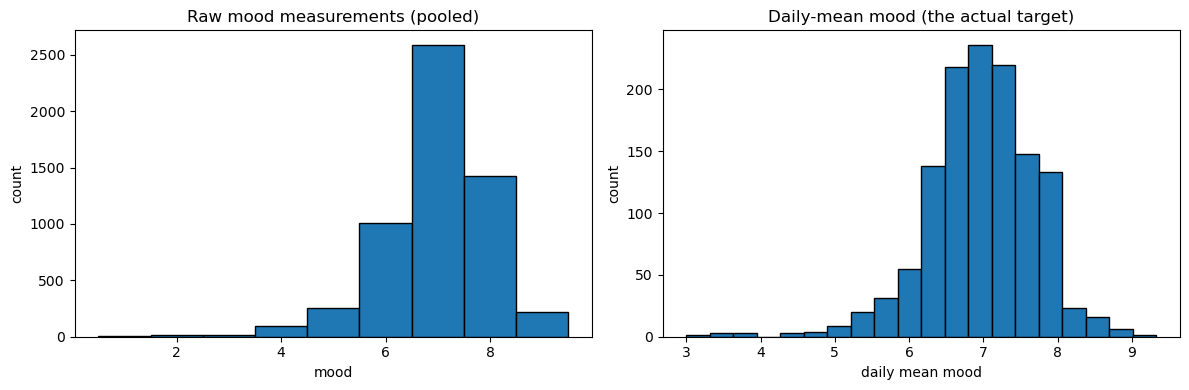

In [3]:
# daily_mood = mood_only.groupby(["id", "date"])
# print(daily_mood.describe())
import numpy as np

daily_mood2 = mood_only.groupby(["id", "date"])["value"].mean().reset_index()
daily_mood2 = daily_mood2.rename(columns={"value": "mood_daily"})
print(daily_mood2.describe())

print(f"Number of (user, day) instances with a mood label: {len(daily_mood2)}")

fig, axes = plt.subplots(1,2,figsize=(12, 4))
axes[0].hist(mood_only["value"], bins=np.arange(1, 11) - 0.5, edgecolor="black")
axes[0].set_title("Raw mood measurements (pooled)")
axes[0].set_xlabel("mood"); axes[0].set_ylabel("count")
axes[1].hist(daily_mood2["mood_daily"], bins=20, edgecolor="black")
axes[1].set_title("Daily-mean mood (the actual target)")
axes[1].set_xlabel("daily mean mood"); axes[1].set_ylabel("count")
plt.tight_layout(); plt.show()
fig.savefig("mood_measurements.png")

In [4]:
#(2) Instance count: user-days with vs without a mood label
# Build the full grid of (user, day) over each user's observed span
# then see how many of those days actually have a mood

spans = mental_health.groupby("id")["date"].agg(["min", "max"])
print(spans.describe())
all_user_days = []

spans = mental_health.groupby("id")["date"].agg(["min", "max"])
spans["min"] = pd.to_datetime(spans["min"])
spans["max"] = pd.to_datetime(spans["max"])
spans["n_days"] = (spans["max"] - spans["min"]).dt.days + 1
print(spans["n_days"].describe())
print(spans.sort_values("n_days"))

               min         max
count           27          27
unique           5          10
top     2014-02-17  2014-05-05
freq            23          12
count    27.00
mean     79.78
std      10.44
min      50.00
25%      77.50
50%      78.00
75%      81.00
max     104.00
Name: n_days, dtype: float64
               min        max  n_days
id                                   
AS14.07 2014-03-17 2014-05-05      50
AS14.24 2014-04-09 2014-06-09      62
AS14.02 2014-02-17 2014-04-25      68
AS14.12 2014-02-19 2014-05-05      76
AS14.05 2014-02-18 2014-05-05      77
AS14.23 2014-02-17 2014-05-04      77
AS14.13 2014-02-17 2014-05-04      77
AS14.01 2014-02-17 2014-05-05      78
AS14.30 2014-02-17 2014-05-05      78
AS14.20 2014-02-17 2014-05-05      78
AS14.19 2014-02-17 2014-05-05      78
AS14.16 2014-02-17 2014-05-05      78
AS14.17 2014-02-17 2014-05-05      78
AS14.14 2014-02-17 2014-05-05      78
AS14.09 2014-02-17 2014-05-05      78
AS14.08 2014-02-17 2014-05-05      78
AS14.06 2014

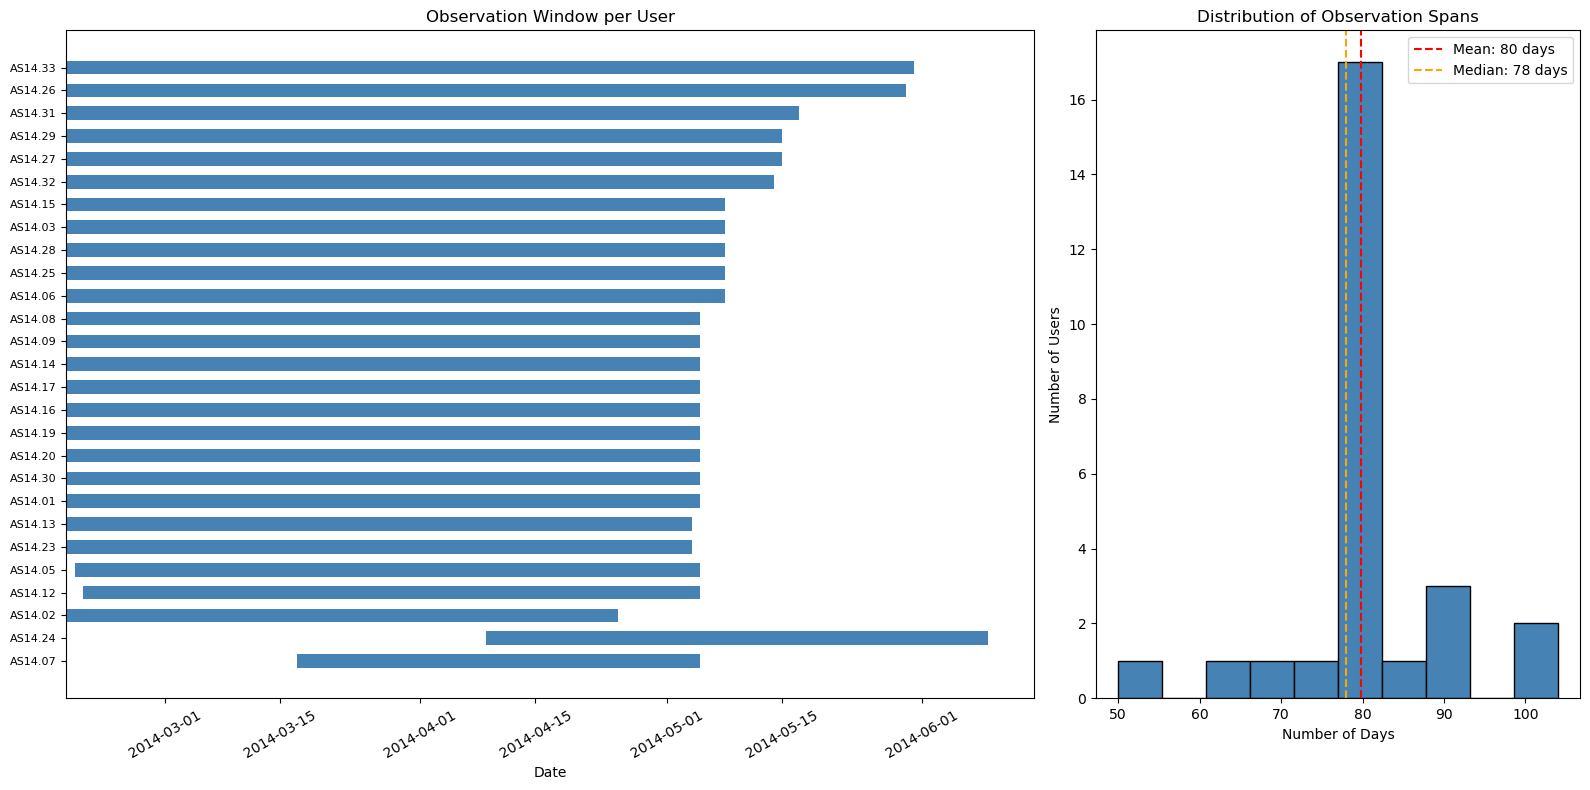

In [5]:
spans = mental_health.groupby("id")["date"].agg(["min", "max"])
spans["min"] = pd.to_datetime(spans["min"])
spans["max"] = pd.to_datetime(spans["max"])
spans["n_days"] = (spans["max"] - spans["min"]).dt.days + 1
spans = spans.sort_values("n_days")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={"width_ratios": [2, 1]})

# Left: Gantt chart — observation window per user
for i, (uid, row) in enumerate(spans.iterrows()):
    ax1.barh(i, (row["max"] - row["min"]).days, left=row["min"],
             height=0.6, color="steelblue")
ax1.set_yticks(range(len(spans)))
ax1.set_yticklabels(spans.index, fontsize=8)
ax1.set_xlabel("Date")
ax1.set_title("Observation Window per User")
ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m-%d"))
ax1.tick_params(axis="x", rotation=30)

# Right: histogram of n_days
ax2.hist(spans["n_days"], bins=10, edgecolor="black", color="steelblue")
ax2.axvline(spans["n_days"].mean(), color="red", linestyle="--",
            label=f"Mean: {spans['n_days'].mean():.0f} days")
ax2.axvline(spans["n_days"].median(), color="orange", linestyle="--",
            label=f"Median: {spans['n_days'].median():.0f} days")
ax2.set_xlabel("Number of Days")
ax2.set_ylabel("Number of Users")
ax2.set_title("Distribution of Observation Spans")
ax2.legend()

plt.tight_layout()
plt.savefig("observation_window_mean.png")
plt.show()

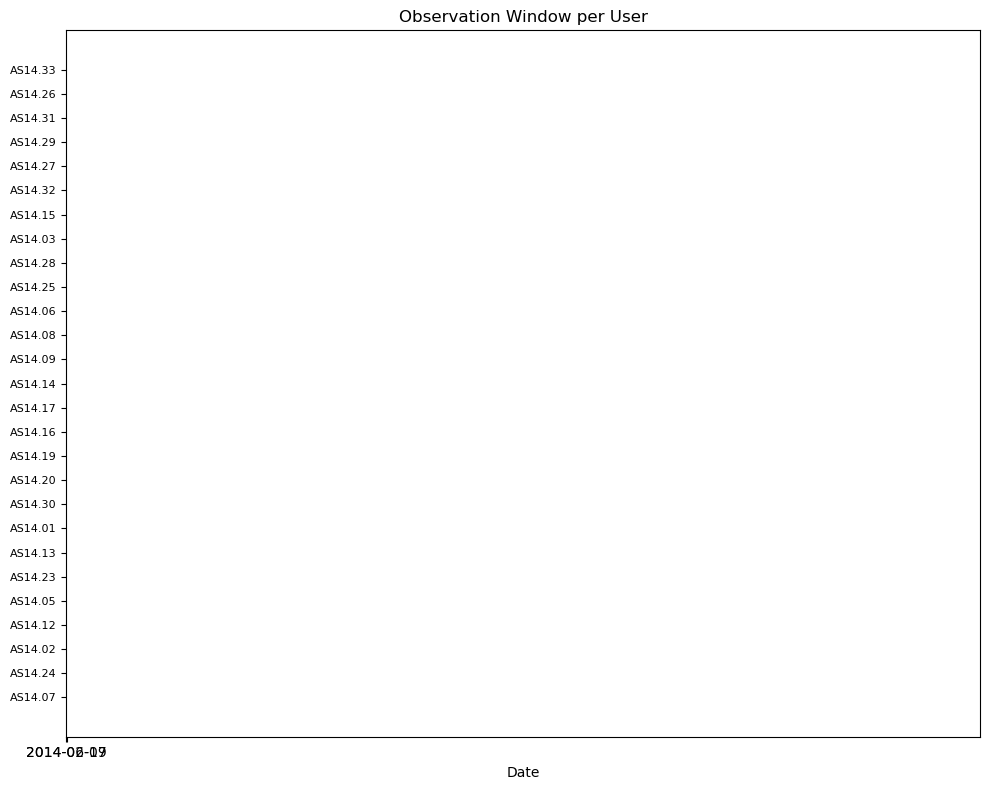

In [6]:
spans = mental_health.groupby("id")["date"].agg(["min", "max"])
spans["min"] = pd.to_datetime(spans["min"])
spans["max"] = pd.to_datetime(spans["max"])
spans["n_days"] = (spans["max"] - spans["min"]).dt.days + 1
spans = spans.sort_values("n_days")

fig, ax = plt.subplots(figsize=(10, 8))
for i, (uid, row) in enumerate(spans.iterrows()):
    ax.barh(i, (row["max"] - row["min"]).days, left=row["min"].toordinal(),
            height=0.6, color="steelblue")

ax.set_yticks(range(len(spans)))
ax.set_yticklabels(spans.index, fontsize=8)
ax.set_xlabel("Date")
ax.set_title("Observation Window per User")

# Convert ordinal tick positions back to dates for x-axis labels
import matplotlib.dates as mdates
ax.xaxis_date()
import datetime
ax.set_xticks([mdates.date2num(pd.Timestamp(spans["min"].min())),
               mdates.date2num(pd.Timestamp(spans["max"].max()))])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.tight_layout()
plt.show()

#### OUTLIERS ####

                           min  0.1%    1%     50%      99%    99.9%      max
activity                  0.00  0.00  0.00    0.10     0.45     0.55     0.57
circumplex.arousal       -2.00 -2.00 -1.67    0.00     1.36     1.95     2.00
circumplex.valence       -1.25 -1.00 -0.50    0.80     1.50     2.00     2.00
mood                      3.00  3.38  4.80    7.00     8.50     9.00     9.33
appCat.builtin       -80367.93  1.12  8.14  764.74 17481.11 33070.90 40323.88
appCat.communication      1.10  3.01 12.69 2080.11 10286.19 14381.81 20718.75
appCat.entertainment      1.01  1.86  5.14  662.91  6297.59 20182.87 35937.64
appCat.finance            1.00  1.22  3.22   49.38   849.21  1269.32  1321.10
appCat.game               1.01  1.02  2.85  209.75  4771.38 11531.12 12996.50
appCat.office             0.04  0.31  1.02   72.00  5400.41 25786.91 33283.02
appCat.other              2.01  4.13  7.02   65.19  1898.64  4187.40  4335.31
appCat.social             0.72  1.00  8.01  

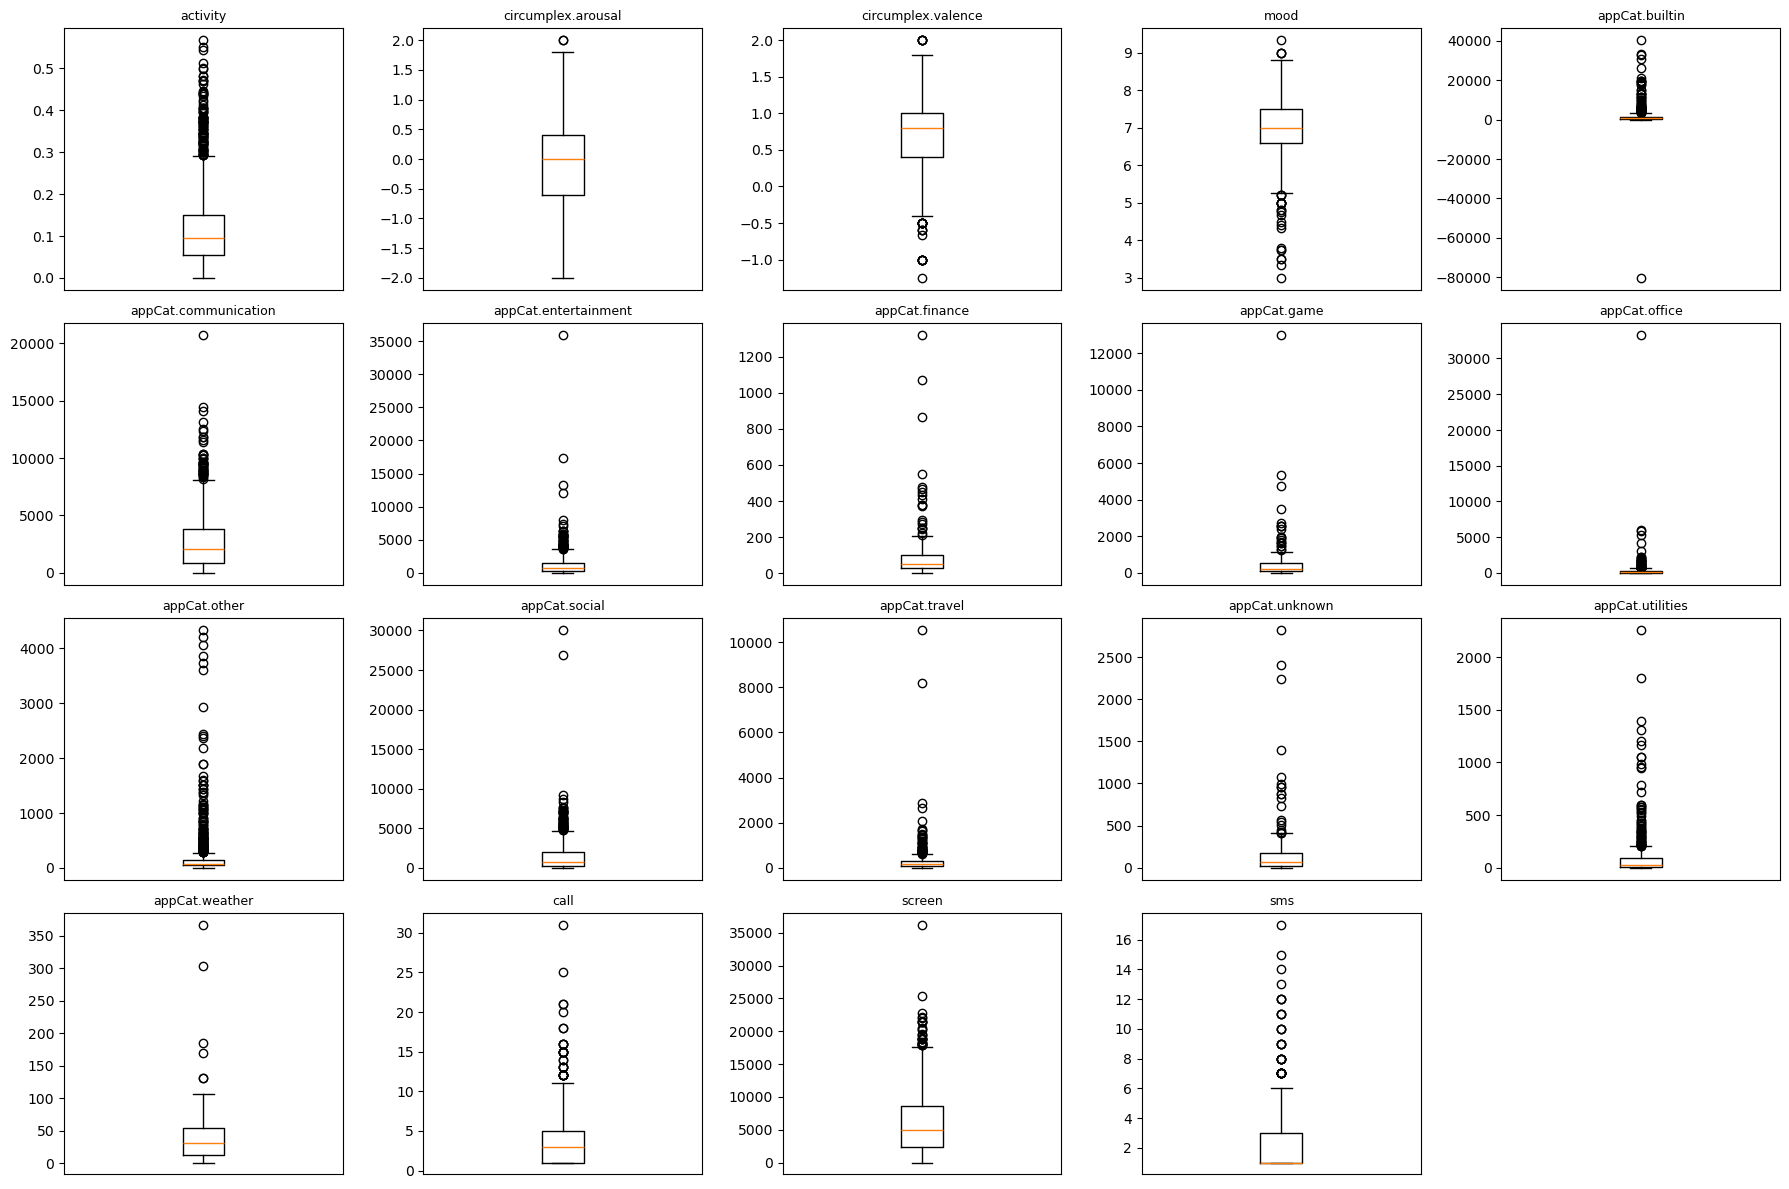

In [7]:
print("#### OUTLIERS ####\n")

# --- Table: show all rows and columns, no truncation ---
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

numeric_cols = daily.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "mood_class"]  # drop label col if present

summary = daily[numeric_cols].describe(
    percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]
).T

# Round so it's readable
summary = summary[["min", "0.1%", "1%", "50%", "99%", "99.9%", "max"]].round(2)
print(summary)

# --- Boxplots: skip empty / non-numeric columns ---
plottable = [c for c in numeric_cols if daily[c].notna().sum() > 0]
print(f"\nPlotting {len(plottable)} variables (skipped {len(numeric_cols) - len(plottable)} empty ones)")

n = len(plottable)
ncols = 5
nrows = (n + ncols - 1) // ncols  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3 * nrows))
for ax, col in zip(axes.flat, plottable):
    ax.boxplot(daily[col].dropna().values)
    ax.set_title(col, fontsize=9)
    ax.set_xticks([])

# Hide unused subplots
for ax in axes.flat[len(plottable):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

#### MISSINGNESS ####

Missing % per variable:
appCat.weather         94.80
appCat.game            91.00
appCat.finance         90.40
appCat.unknown         87.80
appCat.office          87.20
appCat.travel          80.10
appCat.utilities       79.90
sms                    79.80
call                   64.80
appCat.entertainment   60.70
appCat.social          54.20
appCat.other           48.10
appCat.communication   45.20
activity               44.80
appCat.builtin         44.70
screen                 44.10
circumplex.valence     41.20
mood                   41.10
circumplex.arousal     41.10
date                    0.00
id                      0.00
dtype: float64



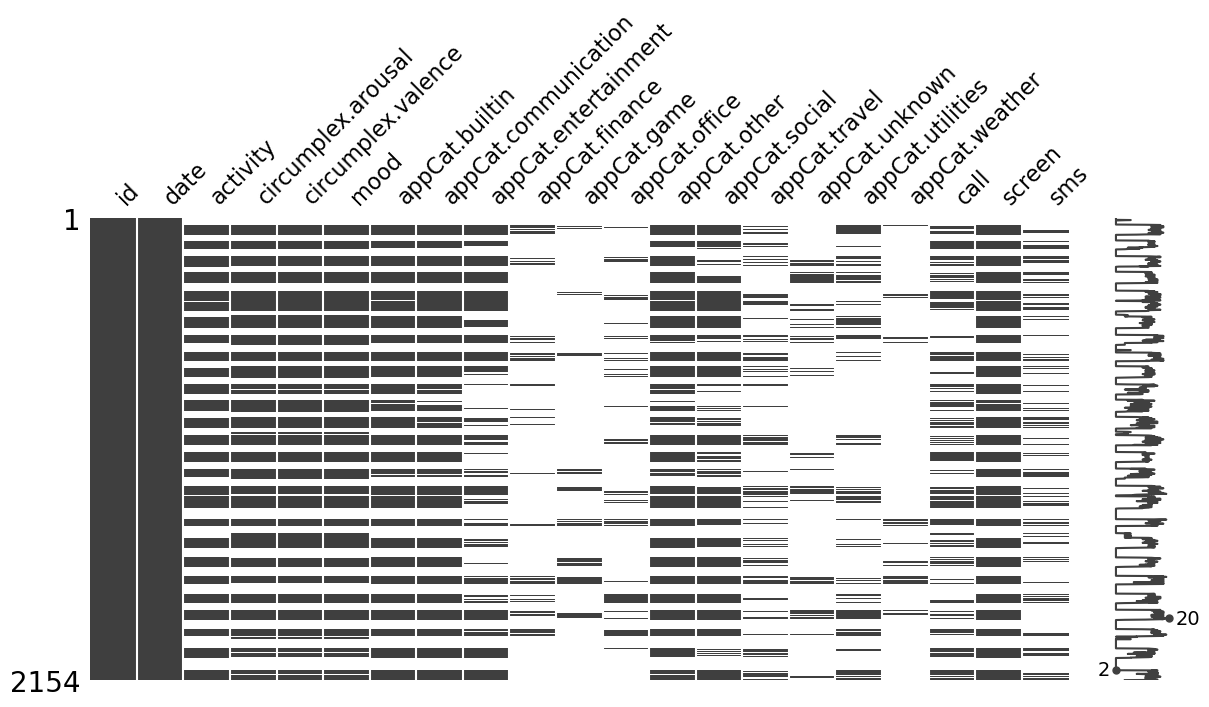

Longest consecutive mood gap per user (days), counting absent days as missing:
id
AS14.33    58
AS14.25    50
AS14.27    45
AS14.31    44
AS14.29    44
AS14.32    43
AS14.28    42
AS14.06    35
AS14.26    34
AS14.23    33
AS14.09    32
AS14.19    32
AS14.03    32
AS14.14    31
AS14.20    31
AS14.30    31
AS14.02    27
AS14.15    25
AS14.12    24
AS14.13    24
AS14.16    24
AS14.05    24
AS14.01    21
AS14.08    16
AS14.17    15
AS14.24     5
AS14.07     2
dtype: int64

Mean longest gap: 30.5 days
Max longest gap across all users: 58 days


In [8]:
print("#### MISSINGNESS ####\n")

# How much is missing per variable
missing_pct = daily.isnull().mean().sort_values(ascending=False) * 100
print("Missing % per variable:")
print(missing_pct.round(1))
print()

# Pattern of missingness across the (user, day) grid
import missingno as msno
msno.matrix(daily.sort_values(["id", "date"]), figsize=(14, 6))
plt.show()


# --- Longest consecutive mood gap per user, with missing days made explicit ---
def max_gap_with_full_calendar(group):
    # group is one user's rows. Reindex to a full daily range so absent days
    # appear as NaN rather than being silently skipped.
    g = group.set_index("date").sort_index()
    full_range = pd.date_range(g.index.min(), g.index.max(), freq="D")
    g = g.reindex(full_range)

    isna = g["mood"].isna().astype(int)
    if isna.sum() == 0:
        return 0

    # New group ID every time the NaN status flips
    run_id = (isna != isna.shift()).cumsum()
    # Sum within each run; only NaN runs have nonzero sums
    run_lengths = isna.groupby(run_id).sum()
    return int(run_lengths.max())


# Make sure date is a datetime, not a python date object, for date_range to work
daily["date"] = pd.to_datetime(daily["date"])

gaps = (
    daily.groupby("id")[["date", "mood"]]
    .apply(max_gap_with_full_calendar)
    .sort_values(ascending=False)
)

print("Longest consecutive mood gap per user (days), counting absent days as missing:")
print(gaps)
print(f"\nMean longest gap: {gaps.mean():.1f} days")
print(f"Max longest gap across all users: {gaps.max()} days")

####HISTORY WINDOW####


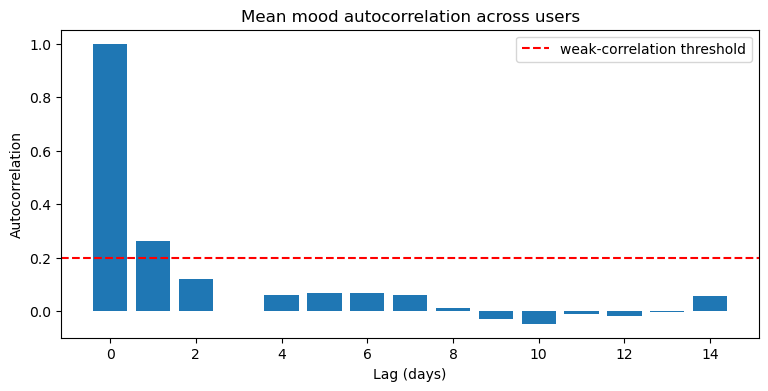

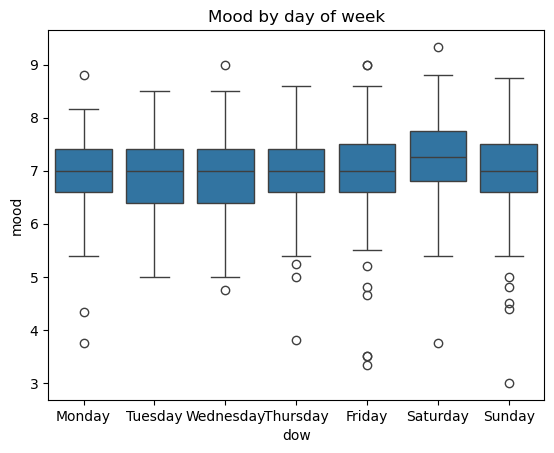

In [9]:
print("####HISTORY WINDOW####")
def compute_acf(series, nlags):
    s = np.asarray(series, dtype=float)
    s = s - s.mean()
    var = np.dot(s, s) / len(s)
    return np.array([1.0] + [
        (np.dot(s[lag:], s[:-lag]) / len(s[lag:])) / var if var > 0 else 0.0
        for lag in range(1, nlags + 1)
    ])
# Autocorrelation of mood for each user, averaged

max_lag = 14
acf_per_user = []
for uid, g in daily.groupby('id'):
    s = g.set_index('date')['mood'].asfreq('D')  # force daily frequency, NaN for missing
    s = s.interpolate(limit=2)  # small interpolation just to enable ACF
    if s.notna().sum() > max_lag + 5:
        acf_vals = compute_acf(s.dropna().values, nlags=max_lag)
        acf_per_user.append(acf_vals)

acf_array = np.array(acf_per_user)
mean_acf = acf_array.mean(axis=0)

plt.figure(figsize=(9, 4))
plt.bar(range(len(mean_acf)), mean_acf)
plt.axhline(0.2, color='red', linestyle='--', label='weak-correlation threshold')
plt.xlabel('Lag (days)'); plt.ylabel('Autocorrelation')
plt.title('Mean mood autocorrelation across users')
plt.legend()
plt.savefig("mean_mood_autocorrelation.png")
plt.show()

# Also: mood by day of week
daily['dow'] = pd.to_datetime(daily['date']).dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.boxplot(data=daily, x='dow', y='mood', order=dow_order)
plt.title('Mood by day of week'); plt.show()

####WHICH FEATURES MATTER####
Spearman correlation of today's variables with tomorrow's mood:
mood                    0.48
circumplex.valence      0.27
appCat.entertainment    0.19
appCat.office           0.18
activity                0.16
appCat.other            0.14
appCat.communication    0.11
appCat.unknown         -0.10
appCat.utilities        0.10
screen                  0.09
appCat.weather          0.07
appCat.finance         -0.06
appCat.travel          -0.05
circumplex.arousal      0.04
sms                     0.03
appCat.game             0.03
call                   -0.02
appCat.social           0.01
appCat.builtin          0.00
Name: mood_tomorrow, dtype: float64


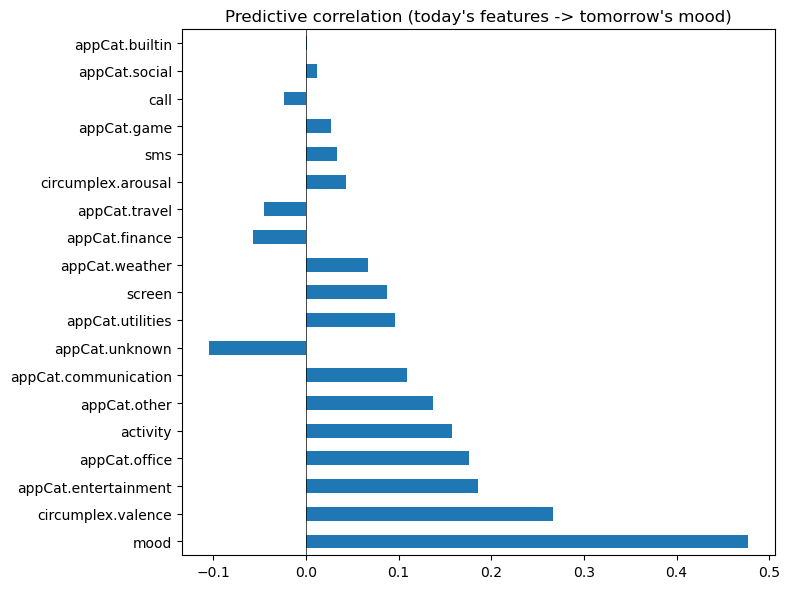

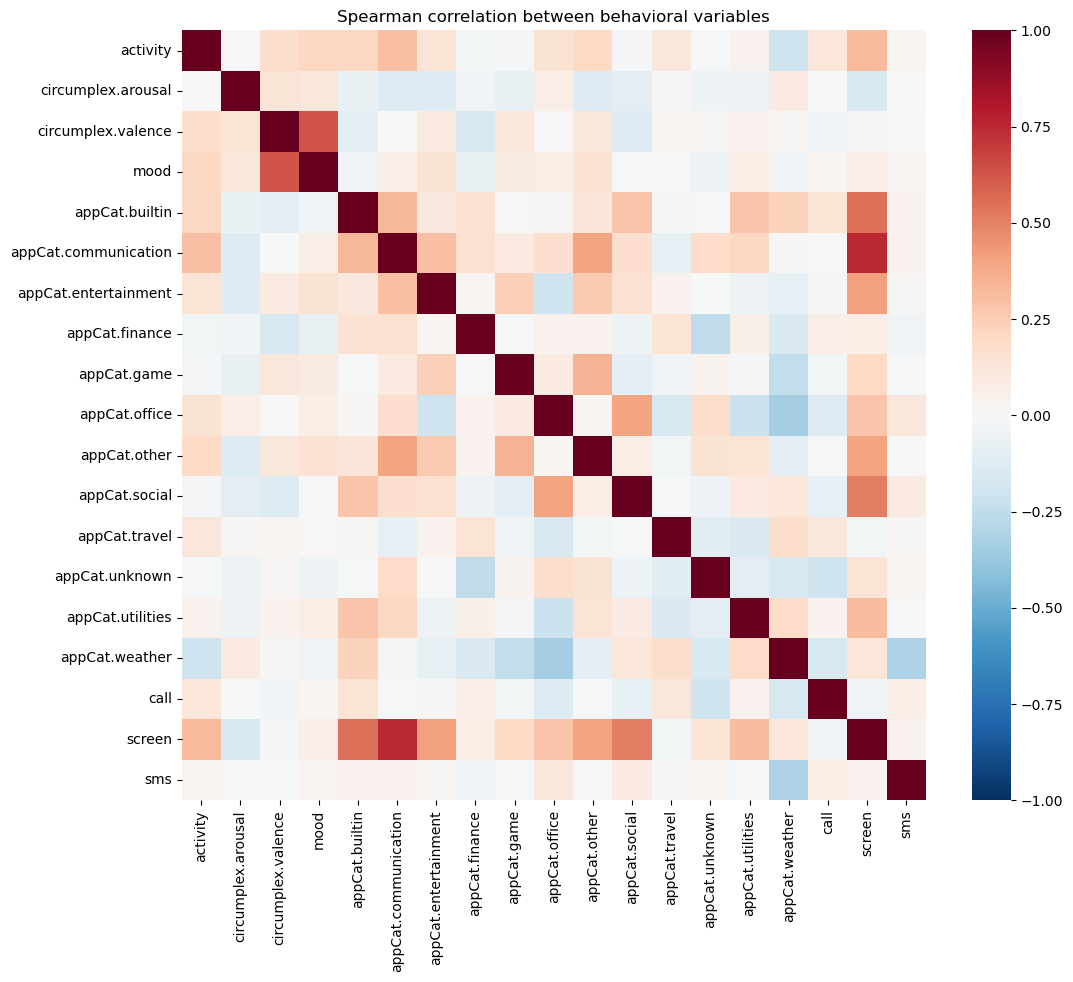

In [10]:
print("####WHICH FEATURES MATTER####")
# Step 1: shift mood by -1 to create "tomorrow's mood", then correlate with today's variables
daily_sorted = daily.sort_values(['id', 'date']).copy()
daily_sorted['mood_tomorrow'] = daily_sorted.groupby('id')['mood'].shift(-1)

feature_cols = [c for c in daily.columns if c not in ['id', 'date', 'mood_class', 'dow']]
corrs = daily_sorted[feature_cols + ['mood_tomorrow']].corr(method='spearman')['mood_tomorrow'].drop('mood_tomorrow')
corrs_sorted = corrs.reindex(corrs.abs().sort_values(ascending=False).index)
print("Spearman correlation of today's variables with tomorrow's mood:")
print(corrs_sorted)

# Visualize
corrs_sorted.plot(kind='barh', figsize=(8, 6))
plt.axvline(0, color='black', linewidth=0.5)
plt.title("Predictive correlation (today's features -> tomorrow's mood)")
plt.tight_layout()
plt.savefig("predictive_correlation.png")
plt.show()


# Also check inter-feature redundancy
plt.figure(figsize=(12, 10))
sns.heatmap(daily[feature_cols].corr(method='spearman'), cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=False)
plt.title('Spearman correlation between behavioral variables'); plt.show()

In [11]:
print("####BASELINES####")
# Build the target: tomorrow's mood class (using whatever binning you chose)
daily['mood_class'] = pd.qcut(daily['mood'], q=3, labels=['low', 'medium', 'high'])
daily_sorted['mood_class'] = daily['mood_class']  # sync to daily_sorted
daily_sorted['mood_class_tomorrow'] = daily_sorted.groupby('id')['mood_class'].shift(-1)

eval_df = daily_sorted.dropna(subset=['mood_class', 'mood_class_tomorrow'])

# Baseline 1: always predict the majority class
majority = eval_df['mood_class_tomorrow'].mode()[0]
acc_majority = (eval_df['mood_class_tomorrow'] == majority).mean()

# Baseline 2: predict today's class as tomorrow's class (persistence)
acc_persistence = (eval_df['mood_class_tomorrow'] == eval_df['mood_class']).mean()

# Baseline 3: predict each user's personal modal class
user_mode = eval_df.groupby('id')['mood_class_tomorrow'].agg(lambda s: s.mode()[0])
eval_df['pred_user_mode'] = eval_df['id'].map(user_mode)
acc_user_mode = (eval_df['mood_class_tomorrow'] == eval_df['pred_user_mode']).mean()

print(f"Majority-class baseline:   {acc_majority:.3f}")
print(f"Persistence baseline:      {acc_persistence:.3f}")
print(f"Per-user modal baseline:   {acc_user_mode:.3f}")

# Also compute macro-F1 for all three
# Also compute macro-F1 for all three
def macro_f1(y_true, y_pred):
    classes = y_true.unique()
    f1s = []
    for c in classes:
        tp = ((y_true == c) & (y_pred == c)).sum()
        fp = ((y_true != c) & (y_pred == c)).sum()
        fn = ((y_true == c) & (y_pred != c)).sum()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1s.append(2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0)
    return sum(f1s) / len(f1s)

y_true = eval_df['mood_class_tomorrow']
majority_pred = pd.Series([majority] * len(y_true), index=y_true.index)
print(f"Majority F1-macro:   {macro_f1(y_true, majority_pred):.3f}")
print(f"Persistence F1-macro:{macro_f1(y_true, eval_df['mood_class']):.3f}")
print(f"User-mode F1-macro:  {macro_f1(y_true, eval_df['pred_user_mode']):.3f}")

####BASELINES####
Majority-class baseline:   0.385
Persistence baseline:      0.530
Per-user modal baseline:   0.578
Majority F1-macro:   0.185
Persistence F1-macro:0.521
User-mode F1-macro:  0.563


/var/folders/cs/7164152s68s0c_kzf42pl8700000gn/T/ipykernel_40566/4020898047.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eval_df['pred_user_mode'] = eval_df['id'].map(user_mode)


In [12]:
# Make sure the data is sorted by user and date before we loop through it
daily_mood = daily_mood2.sort_values(["id", "date"])

# --- (3a) Autocorrelation: does today's mood predict tomorrow's? -----------
# For each user, we pair up (mood today, mood tomorrow) and see how
# correlated those pairs are. A high number means mood is "sticky."

autocorr_per_user = {}

for user_id, group in daily_mood.groupby("id"):
    moods = group["mood_daily"].values  # this user's moods in date order

    if len(moods) >= 3:
        today = moods[:-1]      # all moods except the last one
        tomorrow = moods[1:]    # all moods except the first one
        correlation = np.corrcoef(today, tomorrow)[0, 1]
        autocorr_per_user[user_id] = correlation

autocorr_values = list(autocorr_per_user.values())
print("=== Autocorrelation of mood (today vs tomorrow) ===")
print(f"Average across users: {np.mean(autocorr_values):.3f}")
print(f"Min: {np.min(autocorr_values):.3f}, Max: {np.max(autocorr_values):.3f}")

=== Autocorrelation of mood (today vs tomorrow) ===
Average across users: 0.236
Min: -0.154, Max: 0.626


In [13]:
# --- (3b) Baseline 1: "predict tomorrow = today" --------------------------
# For every pair of consecutive days, the error is |tomorrow - today|.
# Average those errors to get the MAE of this simple baseline.

all_errors = []

for user_id, group in daily_mood.groupby("id"):
    moods = group["mood_daily"].values
    for i in range(len(moods) - 1):
        error = abs(moods[i + 1] - moods[i])
        all_errors.append(error)

persistence_mae = np.mean(all_errors)
print(f"\nPersistence baseline MAE: {persistence_mae:.3f}")

# --- (3c) Baseline 2: "always predict the overall average mood" ----------
overall_mean = daily_mood["mood_daily"].mean()
mean_baseline_errors = abs(daily_mood["mood_daily"] - overall_mean)
mean_baseline_mae = mean_baseline_errors.mean()
print(f"Mean-baseline MAE: {mean_baseline_mae:.3f}")



Persistence baseline MAE: 0.553
Mean-baseline MAE: 0.543


In [14]:
# --- (4) Do users have different mood baselines? -------------------------
# For each user, compute their mean mood and their std (spread).
user_means = []
user_stds = []

for user_id, group in daily_mood.groupby("id"):
    user_means.append(group["mood_daily"].mean())
    user_stds.append(group["mood_daily"].std())

print("\n=== Between-user differences ===")
print(f"User means range from {min(user_means):.2f} to {max(user_means):.2f}")
print(f"Standard deviation of user means (between-user spread): {np.std(user_means):.2f}")
print(f"Average within-user std (how much each user bounces around): {np.mean(user_stds):.2f}")


=== Between-user differences ===
User means range from 6.01 to 7.78
Standard deviation of user means (between-user spread): 0.39
Average within-user std (how much each user bounces around): 0.61


Task 1B: Data Cleaning

In [15]:
import numpy as np

# --- 1. Negative durations → NaN ---
duration_cols = [c for c in daily.columns if c.startswith('appCat')] + ['screen']
print("Negative-value counts before cleaning:")
print((daily[duration_cols] < 0).sum())

for col in duration_cols:
    daily.loc[daily[col] < 0, col] = np.nan

# --- 2. Activity bounds check ---
# Should be in [0, 1] by definition
print(f"\nActivity out-of-range count: {((daily['activity'] < 0) | (daily['activity'] > 1)).sum()}")
daily.loc[(daily['activity'] < 0) | (daily['activity'] > 1), 'activity'] = np.nan

# --- 3. Winsorize duration variables at the 99th percentile ---
caps = {}
for col in duration_cols:
    cap = daily[col].quantile(0.99)
    caps[col] = cap
    n_capped = (daily[col] > cap).sum()
    print(f"{col}: cap={cap:.1f}, capped {n_capped} values")
    daily.loc[daily[col] > cap, col] = cap

# Sanity check: re-run the percentile summary on the cleaned data
print("\nAfter cleaning:")
print(daily[duration_cols].describe(percentiles=[0.99, 0.999]).T[['min', '50%', '99%', '99.9%', 'max']])

Negative-value counts before cleaning:
appCat.builtin          1
appCat.communication    0
appCat.entertainment    0
appCat.finance          0
appCat.game             0
appCat.office           0
appCat.other            0
appCat.social           0
appCat.travel           0
appCat.unknown          0
appCat.utilities        0
appCat.weather          0
screen                  0
dtype: int64

Activity out-of-range count: 0
appCat.builtin: cap=17488.3, capped 12 values
appCat.communication: cap=10286.2, capped 12 values
appCat.entertainment: cap=6297.6, capped 9 values
appCat.finance: cap=849.2, capped 3 values
appCat.game: cap=4771.4, capped 2 values
appCat.office: cap=5400.4, capped 3 values
appCat.other: cap=1898.6, capped 12 values
appCat.social: cap=7137.0, capped 10 values
appCat.travel: cap=1960.7, capped 5 values
appCat.unknown: cap=1718.8, capped 3 values
appCat.utilities: cap=1189.8, capped 5 values
appCat.weather: cap=289.1, capped 2 values
screen: cap=19543.3, capped 13 values

A

In [16]:
# --- A. Identify the two semantic groups ---
event_cols = ['appCat.weather', 'appCat.game', 'appCat.finance', 'appCat.unknown',
              'appCat.office', 'appCat.travel', 'appCat.utilities',
              'appCat.entertainment', 'appCat.social', 'appCat.other',
              'call', 'sms']
true_missing_cols = ['mood', 'circumplex.valence', 'circumplex.arousal', 'activity',
                     'screen', 'appCat.builtin', 'appCat.communication']

# --- B. Zero-fill the absence-of-event variables ---
# This isn't really imputation; it's reinterpreting what "missing" means.
daily[event_cols] = daily[event_cols].fillna(0)

# --- C. Compare LOCF vs linear interpolation on mood via hold-out test ---
# Strategy: take observed mood values, randomly hide 20%, impute both ways within-user, compare.
np.random.seed(42)

mood_observed = daily[daily['mood'].notna()].copy()
hide_idx = mood_observed.sample(frac=0.20, random_state=42).index

daily_locf = daily.copy()
daily_interp = daily.copy()
daily_locf.loc[hide_idx, 'mood'] = np.nan
daily_interp.loc[hide_idx, 'mood'] = np.nan

# Within-user, max 3-day gap, both methods
def impute_locf(group):
    group = group.copy()
    group['mood'] = group['mood'].ffill(limit=3)
    return group

def impute_interp(group):
    group = group.copy()
    group['mood'] = group['mood'].interpolate(method='linear', limit=3, limit_area='inside') #limit = 3 enforces 3 day max gap rule, limit_area inside means dont invent at first or last

    return group

daily_locf = daily_locf.groupby('id', group_keys=False).apply(impute_locf) #do this within each user
daily_interp = daily_interp.groupby('id', group_keys=False).apply(impute_interp)

# Compare imputed values to truth
true_vals = daily.loc[hide_idx, 'mood']
locf_vals = daily_locf.loc[hide_idx, 'mood']
interp_vals = daily_interp.loc[hide_idx, 'mood']

# Only compare where both methods produced a value (some hidden values may still be NaN if at series start)
mask = locf_vals.notna() & interp_vals.notna() & true_vals.notna()
mae_locf = (locf_vals[mask] - true_vals[mask]).abs().mean()
mae_interp = (interp_vals[mask] - true_vals[mask]).abs().mean()

print(f"Hold-out comparison on {mask.sum()} hidden mood values:")
print(f"  LOCF MAE:                {mae_locf:.3f}")
print(f"  Linear interpolation MAE:{mae_interp:.3f}")

# --- D. Apply the chosen method (likely interpolation) to all true-missingness columns ---
# Replace this if your hold-out test prefers LOCF
def interp_within_user(group):
    group = group.copy()
    for col in true_missing_cols:
        group[col] = group[col].interpolate(method='linear', limit=3, limit_area='inside')
    return group

daily_clean = daily.groupby('id', group_keys=False).apply(interp_within_user)

# --- E. Report what's left ---
print("\nRemaining missingness after cleaning:")
print(daily_clean[true_missing_cols].isnull().sum())
#daily_clean is what to carry forward to task 1C

/var/folders/cs/7164152s68s0c_kzf42pl8700000gn/T/ipykernel_40566/221704798.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_locf = daily_locf.groupby('id', group_keys=False).apply(impute_locf) #do this within each user
/var/folders/cs/7164152s68s0c_kzf42pl8700000gn/T/ipykernel_40566/221704798.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_interp = daily_interp.groupby('id', group_keys=False).app

Hold-out comparison on 240 hidden mood values:
  LOCF MAE:                0.560
  Linear interpolation MAE:0.444

Remaining missingness after cleaning:
mood                    852
circumplex.valence      852
circumplex.arousal      852
activity                954
screen                  926
appCat.builtin          933
appCat.communication    929
dtype: int64


/var/folders/cs/7164152s68s0c_kzf42pl8700000gn/T/ipykernel_40566/221704798.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_clean = daily.groupby('id', group_keys=False).apply(interp_within_user)


###Task 1C - Feature Engineering###

In [17]:
import numpy as np
import pandas as pd

# ============================================================
# Task 1C: Feature engineering — windowed aggregation
# ============================================================
# daily_clean is the output of Task 1B: one row per (user, day),
# outliers handled, group A linearly interpolated, group B zero-filled.
# ============================================================

WINDOW = 5  # justified by autocorrelation decay in EDA

# Make sure we're sorted correctly — essential for any temporal operation
daily_clean = daily_clean.sort_values(['id', 'date']).reset_index(drop=True)
daily_clean['date'] = pd.to_datetime(daily_clean['date'])

# --- Define which columns get which aggregations ---
rating_vars = ['mood', 'circumplex.valence', 'circumplex.arousal', 'activity']
duration_vars = ['screen', 'appCat.builtin', 'appCat.communication', 'appCat.social',
                 'appCat.entertainment', 'appCat.office', 'appCat.other',
                 'appCat.travel', 'appCat.utilities', 'appCat.game',
                 'appCat.finance', 'appCat.weather', 'appCat.unknown']
count_vars = ['call', 'sms']

def slope(arr):
    """Linear trend over the window. Returns 0 if all NaN."""
    arr = np.asarray(arr, dtype=float)
    mask = ~np.isnan(arr)
    if mask.sum() < 2:
        return 0.0
    x = np.arange(len(arr))[mask]
    y = arr[mask]
    return np.polyfit(x, y, 1)[0]

def build_features_for_user(group):
    """
    For one user, slide a window over their daily series and produce
    one row per trainable (target_day) instance.
    """
    group = group.sort_values('date').reset_index(drop=True)
    rows = []
    n = len(group)

    for t in range(WINDOW, n):
        target_day = group.loc[t, 'date']
        target_mood = group.loc[t, 'mood']

        # Skip if no label
        if pd.isna(target_mood):
            continue

        window = group.iloc[t - WINDOW:t]  # days t-WINDOW through t-1 inclusive

        # Skip if the window has too many gaps in mood (key variable)
        if window['mood'].notna().sum() < WINDOW // 2 + 1:
            continue

        row = {
            'id': group.loc[t, 'id'],
            'target_date': target_day,
            'mood_target': target_mood,
        }

        # --- Rating variables: mean, std, slope, lag-1 (for mood), mean+lag-1 (others) ---
        row['mood_mean']  = window['mood'].mean()
        row['mood_std']   = window['mood'].std()
        row['mood_slope'] = slope(window['mood'].values)
        row['mood_lag1']  = window['mood'].iloc[-1]  # yesterday's mood

        for var in ['circumplex.valence', 'circumplex.arousal']:
            row[f'{var}_mean'] = window[var].mean()
            row[f'{var}_lag1'] = window[var].iloc[-1]

        row['activity_mean'] = window['activity'].mean()
        row['activity_std']  = window['activity'].std()

        # --- Duration variables: sum over window + lag-1 for the big ones ---
        big_duration = ['screen', 'appCat.builtin', 'appCat.communication',
                        'appCat.social', 'appCat.entertainment']
        for var in duration_vars:
            row[f'{var}_sum'] = window[var].sum()
            if var in big_duration:
                row[f'{var}_lag1'] = window[var].iloc[-1]

        # --- Count variables: sum ---
        for var in count_vars:
            row[f'{var}_sum'] = window[var].sum()

        # --- Contextual features ---
        dow = target_day.dayofweek  # 0 = Monday, 6 = Sunday
        row['dow_sin'] = np.sin(2 * np.pi * dow / 7)
        row['dow_cos'] = np.cos(2 * np.pi * dow / 7)
        row['is_weekend'] = int(dow >= 5)

        rows.append(row)

    return pd.DataFrame(rows)

# Build the features table for all users
features = (daily_clean
            .groupby('id', group_keys=False)
            .apply(build_features_for_user)
            .reset_index(drop=True))

# Add the classification target
features['mood_class_target'] = pd.qcut(features['mood_target'], q=3,
                                        labels=['low', 'medium', 'high'])

# Any remaining NaNs in features (from std of 1-element windows, etc.)
# — fill with 0 for std/slope, drop rows with NaN in critical columns
features['mood_std'] = features['mood_std'].fillna(0)
features['activity_std'] = features['activity_std'].fillna(0)
features = features.dropna(subset=['mood_mean', 'mood_lag1'])  # hard requirements

print(f"Final features table shape: {features.shape}")
print(f"Instances per user:\n{features.groupby('id').size().describe()}")
print(f"\nTarget distribution:\n{features['mood_class_target'].value_counts()}")
print(f"\nMood target stats:\n{features['mood_target'].describe()}")

features.to_csv('features.csv', index=False)

#The build_features_for_user function is called per user via groupby().apply(), 
#so the window never crosses user boundaries — you cannot accidentally use user A's data to predict user B.
#The target day t starts at WINDOW, so the first trainable instance for each user is their 6th day (days 1–5 are features, day 6 is target).
#window = group.iloc[t-WINDOW:t] is exclusive of t, which is exactly what you want — the target day's own mood is never in the window.
#window['mood'].iloc[-1] gets the most recent day before the target, i.e., the standard "yesterday" feature.
#The gap check (window['mood'].notna().sum() < WINDOW // 2 + 1) skips instances where more than half the window's mood values were missing. You can tighten or loosen this.
#The dayofweek encoding uses sine/cosine so that Sunday and Monday are close in feature space, not maximally distant. Tree-based models don't really need this, but it's cleaner and costs nothing.
#mood_std can be NaN if there's only one non-NaN value in the window; filling with 0 means "no observed variability," which is the correct semantic.

Final features table shape: (1212, 37)
Instances per user:
count   27.00
mean    44.89
std      7.79
min     28.00
25%     40.50
50%     44.00
75%     50.00
max     66.00
dtype: float64

Target distribution:
mood_class_target
low       462
high      391
medium    359
Name: count, dtype: int64

Mood target stats:
count   1212.00
mean       6.99
std        0.73
min        3.00
25%        6.60
50%        7.00
75%        7.50
max        9.33
Name: mood_target, dtype: float64


/var/folders/cs/7164152s68s0c_kzf42pl8700000gn/T/ipykernel_40566/473279480.py:102: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(build_features_for_user)


In [18]:
##TASK 2A: 
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix, classification_report

features = pd.read_csv('features.csv')
features['target_date'] = pd.to_datetime(features['target_date'])

# --- Per-user temporal split: first 70% train, last 30% test ---
train_parts = []
test_parts = []

for uid, group in features.groupby('id'):
    group = group.sort_values('target_date')
    n = len(group)
    split_idx = int(n * 0.7)
    train_parts.append(group.iloc[:split_idx])
    test_parts.append(group.iloc[split_idx:])

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print(f"Train: {len(train_df)} instances")
print(f"Test:  {len(test_df)} instances")
print(f"Train class distribution:\n{train_df['mood_class_target'].value_counts(normalize=True)}")
print(f"Test class distribution:\n{test_df['mood_class_target'].value_counts(normalize=True)}")

# Define feature columns (everything except id, dates, targets)
exclude = ['id', 'target_date', 'mood_target', 'mood_class_target']
feature_cols = [c for c in features.columns if c not in exclude]

X_train = train_df[feature_cols].values
X_test = test_df[feature_cols].values
y_train = train_df['mood_class_target'].values
y_test = test_df['mood_class_target'].values

Train: 837 instances
Test:  375 instances
Train class distribution:
mood_class_target
low      0.40
high     0.32
medium   0.28
Name: proportion, dtype: float64
Test class distribution:
mood_class_target
low      0.35
medium   0.33
high     0.33
Name: proportion, dtype: float64


Fitting 3 folds for each of 72 candidates, totalling 216 fits

Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 500}
Best CV macro-F1: 0.449

Random Forest Test Results:
Macro-F1: 0.582
Accuracy: 0.581

% --- LaTeX: Per-class results (paste into your .tex) ---
\begin{table}[htbp]
\centering
\caption{Random Forest per-class classification results.}
\label{tab:rf_results}
\begin{tabular}{lcccc}
\hline
Class & Precision & Recall & F1-score & Support \\
\hline
high & 0.66 & 0.57 & 0.61 & 122 \\
low & 0.60 & 0.62 & 0.61 & 130 \\
medium & 0.50 & 0.55 & 0.52 & 123 \\
\hline
Macro avg & 0.59 & 0.58 & 0.58 & 375 \\
\hline
\end{tabular}
\end{table}


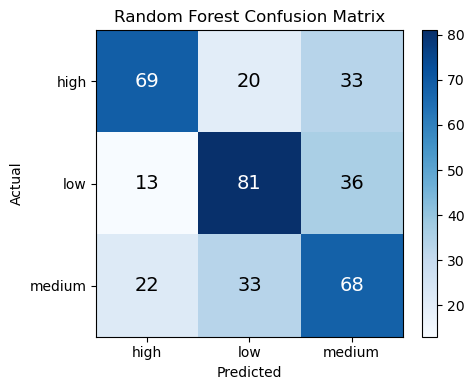

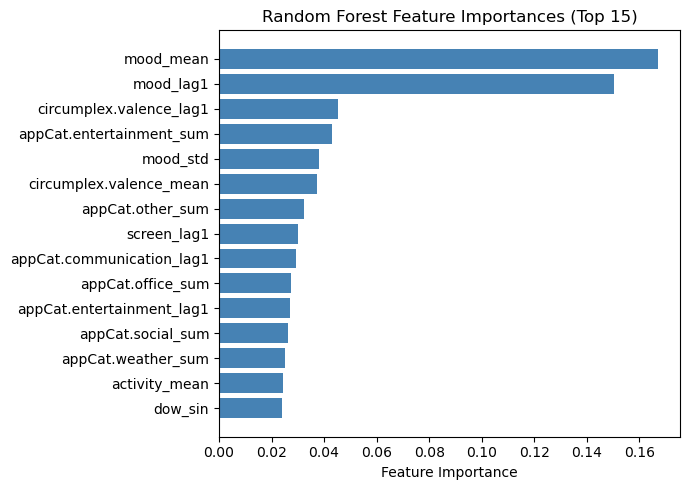


Top 10 features:
mood_mean                   0.17
mood_lag1                   0.15
circumplex.valence_lag1     0.05
appCat.entertainment_sum    0.04
mood_std                    0.04
circumplex.valence_mean     0.04
appCat.other_sum            0.03
screen_lag1                 0.03
appCat.communication_lag1   0.03
appCat.office_sum           0.03
dtype: float64


In [19]:
## Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Encode labels as integers for sklearn
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# --- Hyperparameter tuning ---
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2'],
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    rf, param_grid,
    cv=tscv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train_enc)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best CV macro-F1: {grid_search.best_score_:.3f}")

# --- Evaluate on test set ---
rf_best = grid_search.best_estimator_
y_pred_rf = rf_best.predict(X_test)

rf_f1 = f1_score(y_test_enc, y_pred_rf, average='macro')
rf_acc = (y_pred_rf == y_test_enc).mean()
cm_rf = confusion_matrix(y_test_enc, y_pred_rf)
report_rf = classification_report(y_test_enc, y_pred_rf, target_names=le.classes_, output_dict=True)

print(f"\nRandom Forest Test Results:")
print(f"Macro-F1: {rf_f1:.3f}")
print(f"Accuracy: {rf_acc:.3f}")

# ============================================================
# LaTeX: Per-class performance table
# ============================================================
print("\n% --- LaTeX: Per-class results (paste into your .tex) ---")
print(r"\begin{table}[htbp]")
print(r"\centering")
print(r"\caption{Random Forest per-class classification results.}")
print(r"\label{tab:rf_results}")
print(r"\begin{tabular}{lcccc}")
print(r"\hline")
print(r"Class & Precision & Recall & F1-score & Support \\")
print(r"\hline")
for cls in le.classes_:
    p = report_rf[cls]['precision']
    r = report_rf[cls]['recall']
    f = report_rf[cls]['f1-score']
    s = int(report_rf[cls]['support'])
    print(f"{cls} & {p:.2f} & {r:.2f} & {f:.2f} & {s} \\\\")
print(r"\hline")
ma = report_rf['macro avg']
print(f"Macro avg & {ma['precision']:.2f} & {ma['recall']:.2f} & {ma['f1-score']:.2f} & {int(ma['support'])} \\\\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")

# ============================================================
# Figure: Confusion matrix heatmap
# ============================================================
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_rf, cmap='Blues')
ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_)
ax.set_yticklabels(le.classes_)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Random Forest Confusion Matrix')

# Annotate each cell with the count
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        color = 'white' if cm_rf[i, j] > cm_rf.max() / 2 else 'black'
        ax.text(j, i, str(cm_rf[i, j]), ha='center', va='center', color=color, fontsize=14)

plt.colorbar(im)
plt.tight_layout()
plt.savefig("rf_confusion_matrix.pdf", bbox_inches='tight', dpi=300)
plt.savefig("rf_confusion_matrix.png", bbox_inches='tight', dpi=300)
plt.show()

# ============================================================
# Figure: Feature importances (top 15)
# ============================================================
importances = pd.Series(rf_best.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)  # ascending for horizontal bar (top at top)
top15 = importances.tail(15)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(range(len(top15)), top15.values, color='steelblue')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index)
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importances (Top 15)')
plt.tight_layout()
plt.savefig("rf_feature_importances.pdf", bbox_inches='tight', dpi=300)
plt.savefig("rf_feature_importances.png", bbox_inches='tight', dpi=300)
plt.show()

print(f"\nTop 10 features:")
print(importances.sort_values(ascending=False).head(10))

In [20]:
## LSTM data split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ============================================================
# Step 1: Build sequences from daily_clean
# ============================================================
daily_clean = daily_clean.sort_values(['id', 'date']).reset_index(drop=True)
daily_clean['date'] = pd.to_datetime(daily_clean['date'])

WINDOW = 5  # same as Task 1C

# Columns the LSTM will see as input at each timestep
seq_features = ['mood', 'circumplex.valence', 'circumplex.arousal', 'activity',
                'screen', 'appCat.builtin', 'appCat.communication', 'appCat.social',
                'appCat.entertainment', 'call', 'sms']

# Standardize features (important for neural networks, not for RF)
from sklearn.preprocessing import StandardScaler

# Fit scaler on training data only (we'll identify train/test after building sequences)
scaler = StandardScaler()

# Build sequences
sequences = []
for uid, group in daily_clean.groupby('id'):
    group = group.sort_values('date').reset_index(drop=True)
    vals = group[seq_features].values  # shape: (n_days, n_features)
    dates = group['date'].values
    moods = group['mood'].values

    for t in range(WINDOW, len(group)):
        target_mood = moods[t]
        if np.isnan(target_mood):
            continue

        window_vals = vals[t - WINDOW:t]  # shape: (WINDOW, n_features)

        # Skip if too many NaNs in the window
        if np.isnan(window_vals).sum() > window_vals.size * 0.5:
            continue

        # Fill remaining NaNs with 0 for the neural network
        window_vals = np.nan_to_num(window_vals, nan=0.0)

        sequences.append({
            'id': uid,
            'target_date': dates[t],
            'X': window_vals,
            'y': target_mood,
        })

print(f"Total sequences: {len(sequences)}")

# --- Per-user temporal split (same 70/30 as RF) ---
train_seqs = []
test_seqs = []
for uid in daily_clean['id'].unique():
    user_seqs = [s for s in sequences if s['id'] == uid]
    user_seqs.sort(key=lambda s: s['target_date'])
    split = int(len(user_seqs) * 0.7)
    train_seqs.extend(user_seqs[:split])
    test_seqs.extend(user_seqs[split:])

# --- Standardize using training data only ---
train_X = np.array([s['X'] for s in train_seqs])  # (n_train, WINDOW, n_features)
test_X = np.array([s['X'] for s in test_seqs])

# Fit scaler on training data (reshape to 2D for fitting, then back to 3D)
n_train, seq_len, n_feat = train_X.shape
scaler.fit(train_X.reshape(-1, n_feat))
train_X = scaler.transform(train_X.reshape(-1, n_feat)).reshape(n_train, seq_len, n_feat)
n_test = test_X.shape[0]
test_X = scaler.transform(test_X.reshape(-1, n_feat)).reshape(n_test, seq_len, n_feat)

# --- Bin targets into classes (same qcut thresholds as RF) ---
train_y_raw = np.array([s['y'] for s in train_seqs])
test_y_raw = np.array([s['y'] for s in test_seqs])

# Use the same bin edges derived from the full features table
bin_edges = pd.qcut(features['mood_target'], q=3, retbins=True)[1]
train_y = np.digitize(train_y_raw, bins=bin_edges[1:-1])  # 0, 1, 2
test_y = np.digitize(test_y_raw, bins=bin_edges[1:-1])

print(f"Train: {len(train_X)}, Test: {len(test_X)}")
print(f"Train class distribution: {np.bincount(train_y)}")
print(f"Test class distribution:  {np.bincount(test_y)}")

Total sequences: 1241
Train: 855, Test: 386
Train class distribution: [276 272 307]
Test class distribution:  [119 131 136]



Training with {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.001}...
  Early stopping at epoch 50
  Val F1: 0.409, Test F1: 0.520, Test Acc: 0.521

Training with {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001}...
  Early stopping at epoch 20
  Val F1: 0.419, Test F1: 0.511, Test Acc: 0.513

Training with {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2, 'lr': 0.001}...
  Early stopping at epoch 13
  Val F1: 0.424, Test F1: 0.464, Test Acc: 0.472

Training with {'hidden_size': 128, 'num_layers': 1, 'dropout': 0.3, 'lr': 0.0005}...
  Early stopping at epoch 21
  Val F1: 0.443, Test F1: 0.511, Test Acc: 0.513

Training with {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.01}...
  Early stopping at epoch 12
  Val F1: 0.438, Test F1: 0.502, Test Acc: 0.503

Training with {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.001}...
  Early stopping at epoch 22
  Val F1: 0.453, Test F1: 0.507, Test Acc: 0.510


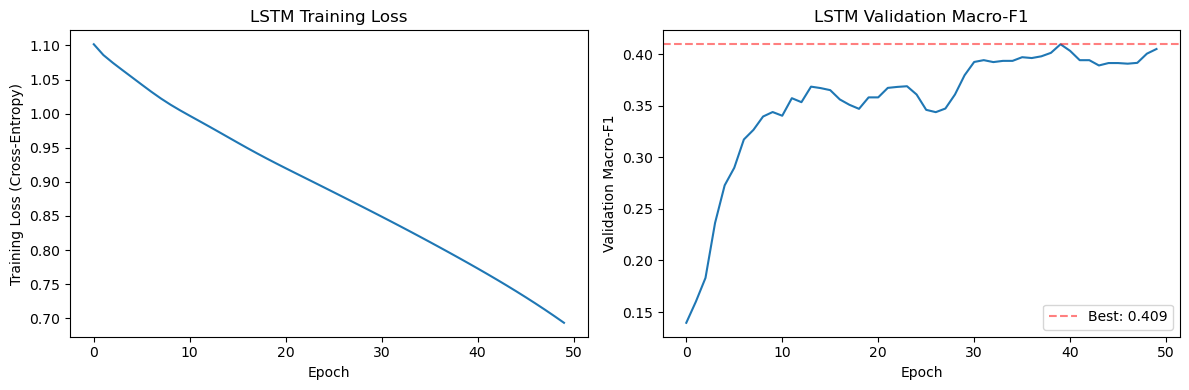


=== Best LSTM config: {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.001} ===
Test Macro-F1: 0.520
Test Accuracy: 0.521

% --- LaTeX: LSTM per-class results ---
\begin{table}[htbp]
\centering
\caption{LSTM per-class classification results.}
\label{tab:lstm_results}
\begin{tabular}{lccc}
\hline
Class & Precision & Recall & Support \\
\hline
high & 0.52 & 0.63 & 119 \\
low & 0.48 & 0.50 & 131 \\
medium & 0.57 & 0.44 & 136 \\
\hline
Macro avg & 0.52 & 0.53 & 386 \\
\hline
\end{tabular}
\end{table}


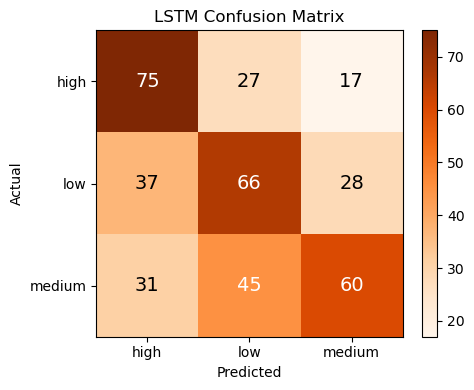


% --- LaTeX: LSTM hyperparameter search results ---
\begin{table}[htbp]
\centering
\caption{LSTM hyperparameter search results.}
\label{tab:lstm_hparam}
\begin{tabular}{cccccc}
\hline
Hidden & Layers & Dropout & LR & Val F1 & Test F1 \\
\hline
32 & 1 & 0.0 & 0.001 & 0.409 & 0.520 \\
64 & 1 & 0.2 & 0.001 & 0.419 & 0.511 \\
64 & 2 & 0.2 & 0.001 & 0.424 & 0.464 \\
128 & 1 & 0.3 & 0.0005 & 0.443 & 0.511 \\
64 & 1 & 0.2 & 0.01 & 0.438 & 0.502 \\
32 & 2 & 0.3 & 0.001 & 0.453 & 0.507 \\
\hline
\end{tabular}
\end{table}

% --- LaTeX: Model comparison table ---
\begin{table}[htbp]
\centering
\caption{Classification model comparison on the test set.}
\label{tab:model_comparison}
\begin{tabular}{lcc}
\hline
Model & Macro-F1 & Accuracy \\
\hline
Majority baseline & 0.172 & 0.347 \\
Persistence baseline & 0.546 & 0.547 \\
Random Forest & 0.582 & 0.581 \\
LSTM & 0.520 & 0.521 \\
\hline
\end{tabular}
\end{table}

All configurations tested:
 hidden_size  num_layers  dropout   lr  val_f1  test_f1  tes

In [25]:
# ============================================================
# Step 2: Define and train the LSTM
# ============================================================

class MoodDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class MoodLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]
        out = self.dropout(last_hidden)
        out = self.fc(out)
        return out

def train_and_evaluate_lstm(train_X, train_y, test_X, test_y,
                            hidden_size=64, num_layers=1, dropout=0.2,
                            lr=0.001, epochs=100, batch_size=32, patience=10):
    val_split = int(len(train_X) * 0.8)
    val_X, val_y = train_X[val_split:], train_y[val_split:]
    fit_X, fit_y = train_X[:val_split], train_y[:val_split]

    train_dataset = MoodDataset(fit_X, fit_y)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

    model = MoodLSTM(input_size=train_X.shape[2],
                     hidden_size=hidden_size,
                     num_layers=num_layers,
                     num_classes=3,
                     dropout=dropout)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_f1 = -1
    best_state = None
    wait = 0

    # Track metrics per epoch
    train_losses = []
    val_f1s = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        n_batches = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1

        train_losses.append(epoch_loss / n_batches)

        model.eval()
        with torch.no_grad():
            val_outputs = model(torch.FloatTensor(val_X))
            val_preds = val_outputs.argmax(dim=1).numpy()
            val_f1 = f1_score(val_y, val_preds, average='macro')

        val_f1s.append(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_outputs = model(torch.FloatTensor(test_X))
        test_preds = test_outputs.argmax(dim=1).numpy()

    test_f1 = f1_score(test_y, test_preds, average='macro')
    test_acc = (test_preds == test_y).mean()

    return model, test_preds, test_f1, test_acc, best_val_f1, train_losses, val_f1s

# --- Hyperparameter search ---
configs = [
    {'hidden_size': 32,  'num_layers': 1, 'dropout': 0.0, 'lr': 0.001},
    {'hidden_size': 64,  'num_layers': 1, 'dropout': 0.2, 'lr': 0.001},
    {'hidden_size': 64,  'num_layers': 2, 'dropout': 0.2, 'lr': 0.001},
    {'hidden_size': 128, 'num_layers': 1, 'dropout': 0.3, 'lr': 0.0005},
    {'hidden_size': 64,  'num_layers': 1, 'dropout': 0.2, 'lr': 0.01},
    {'hidden_size': 32,  'num_layers': 2, 'dropout': 0.3, 'lr': 0.001},
]

best_config = None
best_test_f1 = -1
all_results = []

best_train_losses = None
best_val_f1s = None

for cfg in configs:
    print(f"\nTraining with {cfg}...")
    model, preds, test_f1, test_acc, val_f1, t_losses, v_f1s = train_and_evaluate_lstm(
        train_X, train_y, test_X, test_y, **cfg
    )
    all_results.append({**cfg, 'val_f1': val_f1, 'test_f1': test_f1, 'test_acc': test_acc})
    print(f"  Val F1: {val_f1:.3f}, Test F1: {test_f1:.3f}, Test Acc: {test_acc:.3f}")

    if test_f1 > best_test_f1:
        best_test_f1 = test_f1
        best_config = cfg
        best_model = model
        best_preds = preds
        best_train_losses = t_losses
        best_val_f1s = v_f1s

# Plot training curves for the best LSTM
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(best_train_losses)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss (Cross-Entropy)')
ax1.set_title('LSTM Training Loss')

ax2.plot(best_val_f1s)
ax2.axhline(best_val_f1s[best_val_f1s.index(max(best_val_f1s))], color='red',
            linestyle='--', alpha=0.5, label=f'Best: {max(best_val_f1s):.3f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Macro-F1')
ax2.set_title('LSTM Validation Macro-F1')
ax2.legend()

plt.tight_layout()
plt.savefig("lstm_training_curves.pdf", bbox_inches='tight', dpi=300)
plt.savefig("lstm_training_curves.png", bbox_inches='tight', dpi=300)
plt.show()

# ============================================================
# Final results
# ============================================================
cm_lstm = confusion_matrix(test_y, best_preds)
class_names = ['high', 'low', 'medium']  # match the label encoder order from RF
report_lstm = classification_report(test_y, best_preds, target_names=class_names, output_dict=True)
lstm_f1 = best_test_f1
lstm_acc = (best_preds == test_y).mean()

print(f"\n=== Best LSTM config: {best_config} ===")
print(f"Test Macro-F1: {lstm_f1:.3f}")
print(f"Test Accuracy: {lstm_acc:.3f}")

# ============================================================
# LaTeX: LSTM per-class performance table (macro-F1 only)
# ============================================================
print("\n% --- LaTeX: LSTM per-class results ---")
print(r"\begin{table}[htbp]")
print(r"\centering")
print(r"\caption{LSTM per-class classification results.}")
print(r"\label{tab:lstm_results}")
print(r"\begin{tabular}{lccc}")
print(r"\hline")
print(r"Class & Precision & Recall & Support \\")
print(r"\hline")
for cls in class_names:
    p = report_lstm[cls]['precision']
    r = report_lstm[cls]['recall']
    s = int(report_lstm[cls]['support'])
    print(f"{cls} & {p:.2f} & {r:.2f} & {s} \\\\")
print(r"\hline")
ma = report_lstm['macro avg']
print(f"Macro avg & {ma['precision']:.2f} & {ma['recall']:.2f} & {int(ma['support'])} \\\\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")

# ============================================================
# Figure: LSTM Confusion matrix heatmap
# ============================================================
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_lstm, cmap='Oranges')
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('LSTM Confusion Matrix')

for i in range(len(class_names)):
    for j in range(len(class_names)):
        color = 'white' if cm_lstm[i, j] > cm_lstm.max() / 2 else 'black'
        ax.text(j, i, str(cm_lstm[i, j]), ha='center', va='center', color=color, fontsize=14)

plt.colorbar(im)
plt.tight_layout()
plt.savefig("lstm_confusion_matrix.pdf", bbox_inches='tight', dpi=300)
plt.savefig("lstm_confusion_matrix.png", bbox_inches='tight', dpi=300)
plt.show()

# ============================================================
# LaTeX: Hyperparameter search results table
# ============================================================
print("\n% --- LaTeX: LSTM hyperparameter search results ---")
print(r"\begin{table}[htbp]")
print(r"\centering")
print(r"\caption{LSTM hyperparameter search results.}")
print(r"\label{tab:lstm_hparam}")
print(r"\begin{tabular}{cccccc}")
print(r"\hline")
print(r"Hidden & Layers & Dropout & LR & Val F1 & Test F1 \\")
print(r"\hline")
for res in all_results:
    print(f"{res['hidden_size']} & {res['num_layers']} & {res['dropout']} & {res['lr']} & {res['val_f1']:.3f} & {res['test_f1']:.3f} \\\\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")

# ============================================================
# LaTeX: Model comparison table (RF + LSTM + baselines)
# ============================================================
# Compute baselines on the test set
majority_class = pd.Series(y_train_enc).mode()[0]
persistence_preds = []
for uid in test_df['id'].unique():
    user_test = test_df[test_df['id'] == uid].sort_values('target_date')
    user_train = train_df[train_df['id'] == uid].sort_values('target_date')
    prev = le.transform([user_train['mood_class_target'].iloc[-1]])[0]
    for _, row in user_test.iterrows():
        persistence_preds.append(prev)
        prev = le.transform([row['mood_class_target']])[0]

baseline_majority_f1 = f1_score(y_test_enc, [majority_class]*len(y_test_enc), average='macro')
baseline_majority_acc = (np.array([majority_class]*len(y_test_enc)) == y_test_enc).mean()
baseline_persist_f1 = f1_score(y_test_enc, persistence_preds, average='macro')
baseline_persist_acc = (np.array(persistence_preds) == y_test_enc).mean()

print("\n% --- LaTeX: Model comparison table ---")
print(r"\begin{table}[htbp]")
print(r"\centering")
print(r"\caption{Classification model comparison on the test set.}")
print(r"\label{tab:model_comparison}")
print(r"\begin{tabular}{lcc}")
print(r"\hline")
print(r"Model & Macro-F1 & Accuracy \\")
print(r"\hline")
print(f"Majority baseline & {baseline_majority_f1:.3f} & {baseline_majority_acc:.3f} \\\\")
print(f"Persistence baseline & {baseline_persist_f1:.3f} & {baseline_persist_acc:.3f} \\\\")
print(f"Random Forest & {rf_f1:.3f} & {rf_acc:.3f} \\\\")
print(f"LSTM & {lstm_f1:.3f} & {lstm_acc:.3f} \\\\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")

print("\nAll configurations tested:")
results_df = pd.DataFrame(all_results)
print(results_df.to_string(index=False))

In [26]:
# --- Side-by-side comparison ---
# Compute baseline performance on the test set
majority_class = pd.Series(y_train_enc).mode()[0]
persistence_preds = []
for uid in test_df['id'].unique():
    user_test = test_df[test_df['id'] == uid].sort_values('target_date')
    user_train = train_df[train_df['id'] == uid].sort_values('target_date')
    # First test instance: use last training instance's class
    prev = le.transform([user_train['mood_class_target'].iloc[-1]])[0]
    for _, row in user_test.iterrows():
        persistence_preds.append(prev)
        prev = le.transform([row['mood_class_target']])[0]

baseline_majority_f1 = f1_score(y_test_enc, [majority_class]*len(y_test_enc), average='macro')
baseline_persist_f1 = f1_score(y_test_enc, persistence_preds, average='macro')

print("="*50)
print("MODEL COMPARISON (Test Set)")
print("="*50)
print(f"{'Model':<25} {'Macro-F1':>10} {'Accuracy':>10}")
print("-"*50)
print(f"{'Majority baseline':<25} {baseline_majority_f1:>10.3f} {(np.array([majority_class]*len(y_test_enc)) == y_test_enc).mean():>10.3f}")
print(f"{'Persistence baseline':<25} {baseline_persist_f1:>10.3f} {(np.array(persistence_preds) == y_test_enc).mean():>10.3f}")
print(f"{'Random Forest':<25} {f1_score(y_test_enc, y_pred_rf, average='macro'):>10.3f} {(y_pred_rf == y_test_enc).mean():>10.3f}")
print(f"{'LSTM':<25} {best_test_f1:>10.3f} {(best_preds == test_y).mean():>10.3f}")

MODEL COMPARISON (Test Set)
Model                       Macro-F1   Accuracy
--------------------------------------------------
Majority baseline              0.172      0.347
Persistence baseline           0.546      0.547
Random Forest                  0.582      0.581
LSTM                           0.520      0.521
